# ECG Chagas Project

perform additional EDA for outliers and model selection on split data.


### Set-up

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, roc_curve, precision_recall_curve

### Load Training Data

In [ ]:
# Loading the isolated patient-level splits generated from your preprocessing pipeline
train_df = pd.read_csv("processed_data/train.csv")
val_df = pd.read_csv("processed_data/validation.csv")

target_col = 'target'
# Filter out metadata columns to isolate the 51 structural ECG/demographic features
exclude_cols = [target_col, 'patient_id', 'exam_id']
feature_cols = [col for col in train_df.columns if col not in exclude_cols]

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

print(f"Training feature space:   {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Validation feature space: {X_val.shape[0]} samples, {X_val.shape[1]} features")

### Extended EDA

#### Examining Interaction Between Clinically Known ECG Markers for Chagas Disease

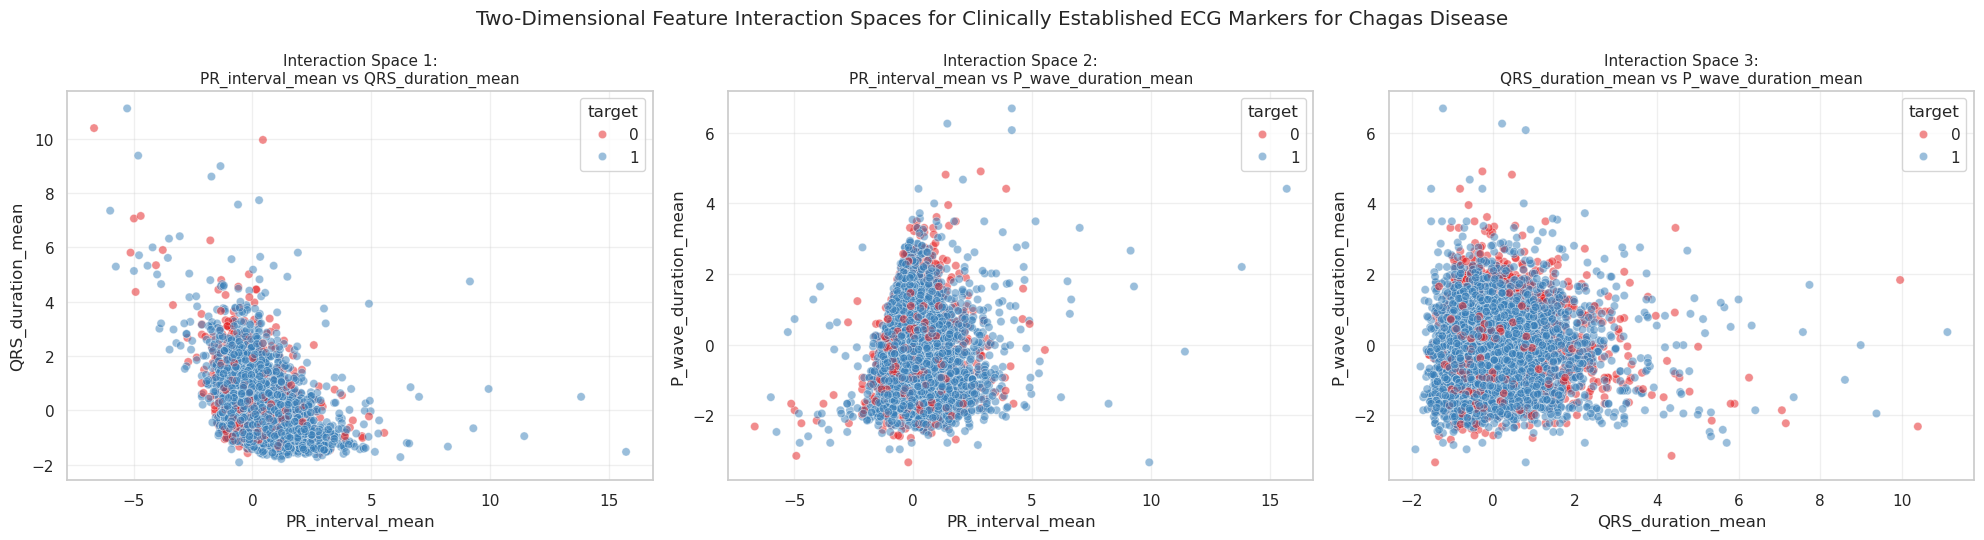

In [71]:
# Define the top 3 known clinical markers
top_features = ['PR_interval_mean', 'QRS_duration_mean', 'P_wave_duration_mean']

# Create a 1x3 row panel to visualize all combinations side-by-side
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# 1. Subplot 1: PR_interval_mean vs QRS_duration_mean
sns.scatterplot(
    ax=axes[0],
    data=train_df,
    x=top_features[0],
    y=top_features[1],
    hue=target_col,
    alpha=0.5,
    palette='Set1'
)
axes[0].set_title(f"Interaction Space 1:\n{top_features[0]} vs {top_features[1]}", fontsize=11)
axes[0].set_xlabel(top_features[0])
axes[0].set_ylabel(top_features[1])
axes[0].grid(True, alpha=0.3)

# 2. Subplot 2: PR_interval_mean vs P_wave_duration_mean
sns.scatterplot(
    ax=axes[1],
    data=train_df,
    x=top_features[0],
    y=top_features[2],
    hue=target_col,
    alpha=0.5,
    palette='Set1'
)
axes[1].set_title(f"Interaction Space 2:\n{top_features[0]} vs {top_features[2]}", fontsize=11)
axes[1].set_xlabel(top_features[0])
axes[1].set_ylabel(top_features[2])
axes[1].grid(True, alpha=0.3)

# 3. Subplot 3: QRS_duration_mean vs P_wave_duration_mean
sns.scatterplot(
    ax=axes[2],
    data=train_df,
    x=top_features[1],
    y=top_features[2],
    hue=target_col,
    alpha=0.5,
    palette='Set1'
)
axes[2].set_title(f"Interaction Space 3:\n{top_features[1]} vs {top_features[2]}", fontsize=11)
axes[2].set_xlabel(top_features[1])
axes[2].set_ylabel(top_features[2])
axes[2].grid(True, alpha=0.3)

plt.suptitle("Two-Dimensional Feature Interaction Spaces for Clinically Established ECG Markers for Chagas Disease")

# Adjust layout
plt.tight_layout()
plt.show()



Observation: These interaction spaces visualize the joint distribution of our top ECG predictors. We observe a heavily overlapping, high-density cloud where Chagas-positive and negative cases are deeply intermingled, with no clear linear separability between classes. This indicates that while a linear model (Logistic Regression) may capture broad directional trends, it will likely struggle to isolate localized risk clusters. Consequently, the use of a non-parametric Random Forest classifier is justified; its ability to partition the feature space into non-linear decision regions allows the model to extract robust signals from these complex, overlapping regions.

#### Feature Selection & Outlier Analysis

Before feeding our data into predictive models (like Logistic Regression and Random Forest), we need to narrow down our 51 original features. 

**Our criteria for selection:**
1. **Information Density:** Features must have actual variance. If a feature is heavily stacked on a single value (zero-variance), it carries no predictive power.
2. **Low Redundancy (Multicollinearity):** Many of our ECG and HRV measurements capture the exact same biological phenomena. Feeding highly correlated features into Logistic Regression causes unstable coefficients.
3. **Biological Relevance:** We want to retain the "gold standard" metrics most relevant to detecting Chagas disease arrhythmias.

In [66]:
# This will calculate Skew, Outlier %, and Mode Concentration.
def analyze_and_visualize_feature(df, column_name, mode_threshold=90.0, skew_threshold=1.5):
    """
    Analyzes a feature for skewness, outliers, and variance. 
    Prints a statistical summary and ONLY plots the distribution if the feature 
    is heavily skewed or highly concentrated.
    """
    data = df[column_name].dropna()
    n = len(data)
    
    # -- 1. Calculate Statistics --
    skewness = data.skew()
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    iqr_lower = Q1 - 1.5 * IQR
    iqr_upper = Q3 + 1.5 * IQR
    outlier_count = ((data < iqr_lower) | (data > iqr_upper)).sum()
    outlier_pct = (outlier_count / n) * 100
    
    mean_val = data.mean()
    std_val = data.std()
    z_lower = mean_val - 3 * std_val
    z_upper = mean_val + 3 * std_val
    
    mode_val = data.mode()[0]
    mode_pct = (data == mode_val).sum() / n * 100
    
    # -- 2. Print Summary Report --
    print(f"{'-'*60}")
    print(f"Feature: {column_name}")
    print(f"  - Skewness:   {skewness:.2f}")
    print(f"  - Outliers:   {outlier_pct:.2f}% ({outlier_count} rows outside IQR)")
    print(f"  - Mode Conc:  {mode_pct:.1f}% of data is exactly {mode_val:.4f}")
    
    # -- 3. Conditional Plotting Rules --
    
    # Rule A: Skip Zero-Variance / Single Tower
    if mode_pct >= mode_threshold:
        print(f"  >>> SKIPPING PLOT: Uninformative feature (Mode >= {mode_threshold}%).")
        print(f"{'-'*60}\n")
        return 
    
    # Rule B: Skip Well-Behaved Distributions
    if abs(skewness) < skew_threshold:
        print(f"  >>> SKIPPING PLOT: Well-behaved distribution (Abs Skew < {skew_threshold}).")
        print(f"{'-'*60}\n")
        return 
    
    # Rule C: Plot the Problematic Features
    print(f"  >>> PLOTTING: High Skew Detected.")
    
    fig, ax = plt.subplots(figsize=(7.5, 3))
    sns.set_theme(style="whitegrid")
    
    sns.histplot(data, kde=True, ax=ax, color='skyblue', bins=40)
    ax.set_title(f'Distribution of {column_name} (Skew: {skewness:.2f})')
    
    ax.axvline(iqr_lower, color='red', linestyle='--', label='IQR Bounds')
    ax.axvline(iqr_upper, color='red', linestyle='--')
    ax.axvline(z_lower, color='green', linestyle=':', label='Z-Score Bounds')
    ax.axvline(z_upper, color='green', linestyle=':')
    
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')
    plt.tight_layout()
    plt.show()
    print(f"{'-'*60}\n")

### Phase 1: Domain-Knowledge Pruning (Intervals & HRV)

Before running any statistical screening, we can proactively drop highly correlated and mathematically redundant features based on cardiovascular domain knowledge.

**1. Pruning Redundant Interval Metrics**
For every structural ECG wave (P, PR, QRS, QT, ST), the dataset includes the `mean`, `std`, `min`, and `max`. Mathematically, the min, max, and mean for a single patient are highly correlated. Feeding all of them into a linear model causes severe multicollinearity. Therefore, we will drop all `_min` and `_max` columns, keeping only the `_mean` (baseline) and `_std` (beat-to-beat variability).

**2. Pruning Redundant HRV Metrics**
Following the clinical guidelines established by the *Task Force of the European Society of Cardiology and the North American Society of Pacing and Electrophysiology* (1996), we will retain only the "Gold Standard" time-domain Heart Rate Variability (HRV) metrics: `MeanNN`, `SDNN`, `RMSSD`, and `pNN50`. The other 15 mathematical derivations of interval spread (such as `IQRNN`, `MadNN`, or `CVNN`) capture the exact same biological variance and are dropped to prevent multicollinearity. 
*(Reference: Circulation. 1996;93:1043–1065)*

In [64]:
# 1. Find all columns that end with '_min' or '_max'
interval_redundant = [col for col in X_train.columns if col.endswith('_min') or col.endswith('_max')]

# 2. Explicitly list the redundant HRV columns we want to drop
hrv_redundant = [
    'HRV_SDSD', 'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 
    'HRV_MCVNN', 'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN', 
    'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI', 'HRV_TINN'
]

# Combine them into one master list of redundant features
all_redundant_cols = interval_redundant + hrv_redundant

print(f"Dropping {len(all_redundant_cols)} mathematically redundant columns based on domain knowledge...")

# Create a pruned dataframe to run our analysis on
X_train_pruned = X_train.drop(columns=all_redundant_cols)

print(f"Features remaining for statistical screening: {X_train_pruned.shape[1]}")

Dropping 29 mathematically redundant columns based on domain knowledge...
Features remaining for statistical screening: 20


##### Phase 2: Automated Feature Screening
Now that the redundant wave features are removed, we run the remaining features through an automated screening function. We are specifically looking for features with a **Mode Concentration > 90%** (meaning almost all patients have the exact same value) and extreme skewness.

------------------------------------------------------------
Feature: P_wave_duration_mean
  - Skewness:   0.21
  - Outliers:   1.50% (116 rows outside IQR)
  - Mode Conc:  1.5% of data is exactly -0.1957
  >>> SKIPPING PLOT: Well-behaved distribution (Abs Skew < 1.5).
------------------------------------------------------------

------------------------------------------------------------
Feature: P_wave_duration_std
  - Skewness:   1.50
  - Outliers:   2.31% (179 rows outside IQR)
  - Mode Conc:  2.6% of data is exactly -0.2815
  >>> SKIPPING PLOT: Well-behaved distribution (Abs Skew < 1.5).
------------------------------------------------------------

------------------------------------------------------------
Feature: PR_interval_mean
  - Skewness:   2.37
  - Outliers:   5.94% (460 rows outside IQR)
  - Mode Conc:  0.9% of data is exactly -0.2047
  >>> PLOTTING: High Skew Detected.


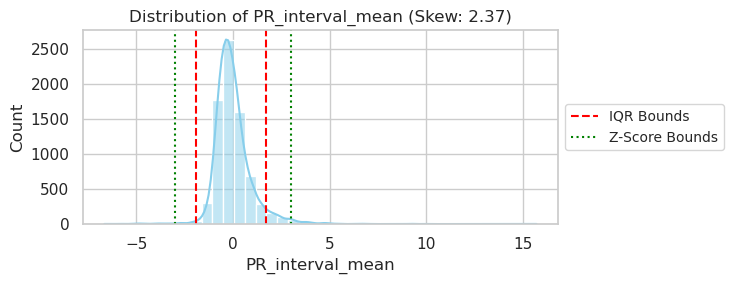

------------------------------------------------------------

------------------------------------------------------------
Feature: PR_interval_std
  - Skewness:   2.79
  - Outliers:   7.93% (614 rows outside IQR)
  - Mode Conc:  2.5% of data is exactly -0.2989
  >>> PLOTTING: High Skew Detected.


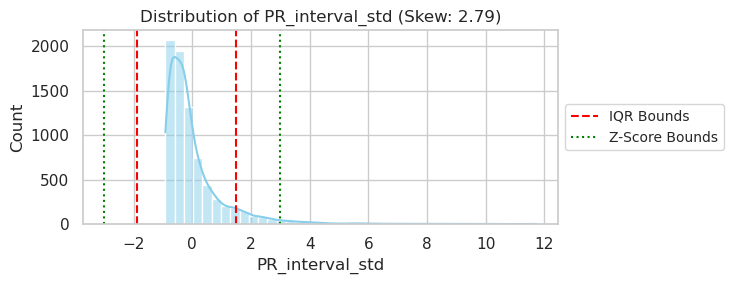

------------------------------------------------------------

------------------------------------------------------------
Feature: PR_segment_mean
  - Skewness:   2.16
  - Outliers:   5.36% (415 rows outside IQR)
  - Mode Conc:  0.8% of data is exactly -0.1214
  >>> PLOTTING: High Skew Detected.


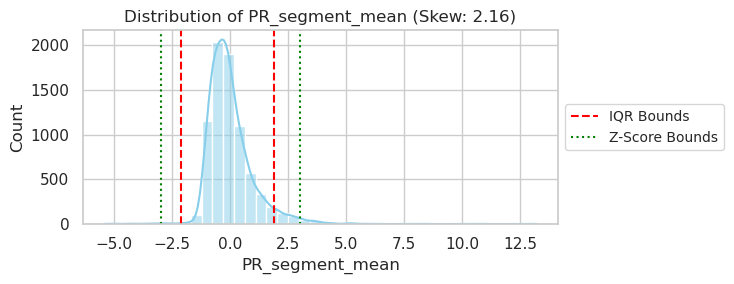

------------------------------------------------------------

------------------------------------------------------------
Feature: PR_segment_std
  - Skewness:   2.46
  - Outliers:   5.47% (424 rows outside IQR)
  - Mode Conc:  2.5% of data is exactly -0.2593
  >>> PLOTTING: High Skew Detected.


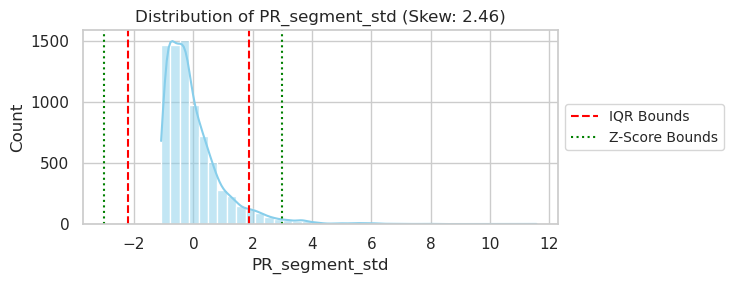

------------------------------------------------------------

------------------------------------------------------------
Feature: QRS_duration_mean
  - Skewness:   2.46
  - Outliers:   3.92% (304 rows outside IQR)
  - Mode Conc:  1.4% of data is exactly -0.7512
  >>> PLOTTING: High Skew Detected.


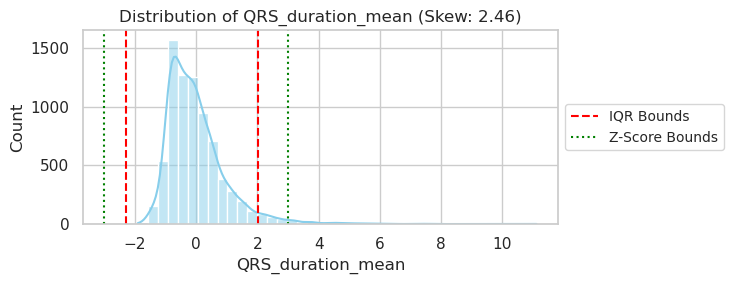

------------------------------------------------------------

------------------------------------------------------------
Feature: QRS_duration_std
  - Skewness:   3.26
  - Outliers:   6.20% (480 rows outside IQR)
  - Mode Conc:  2.5% of data is exactly -0.8649
  >>> PLOTTING: High Skew Detected.


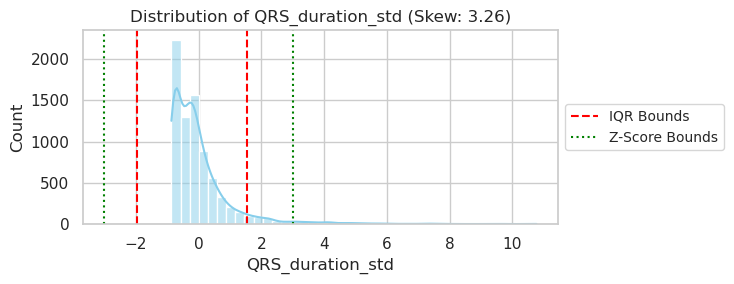

------------------------------------------------------------

------------------------------------------------------------
Feature: QT_interval_mean
  - Skewness:   -0.25
  - Outliers:   5.96% (462 rows outside IQR)
  - Mode Conc:  0.5% of data is exactly 0.2350
  >>> SKIPPING PLOT: Well-behaved distribution (Abs Skew < 1.5).
------------------------------------------------------------

------------------------------------------------------------
Feature: QT_interval_std
  - Skewness:   1.79
  - Outliers:   8.64% (669 rows outside IQR)
  - Mode Conc:  2.5% of data is exactly -0.4312
  >>> PLOTTING: High Skew Detected.


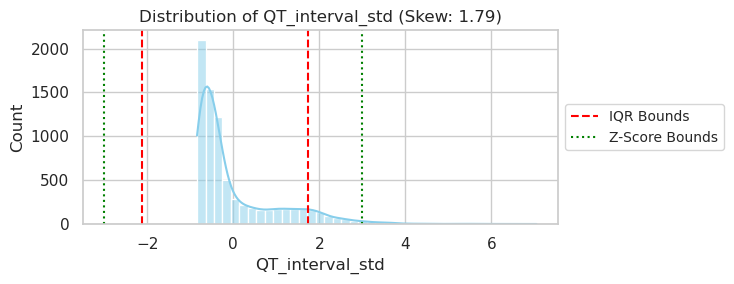

------------------------------------------------------------

------------------------------------------------------------
Feature: ST_segment_mean
  - Skewness:   -0.33
  - Outliers:   5.89% (456 rows outside IQR)
  - Mode Conc:  0.6% of data is exactly 0.3238
  >>> SKIPPING PLOT: Well-behaved distribution (Abs Skew < 1.5).
------------------------------------------------------------

------------------------------------------------------------
Feature: ST_segment_std
  - Skewness:   1.77
  - Outliers:   8.13% (630 rows outside IQR)
  - Mode Conc:  2.5% of data is exactly -0.3833
  >>> PLOTTING: High Skew Detected.


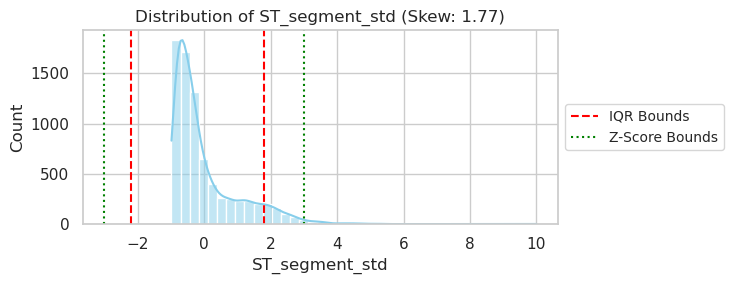

------------------------------------------------------------

------------------------------------------------------------
Feature: ST_slope_mean
  - Skewness:   11.34
  - Outliers:   8.07% (625 rows outside IQR)
  - Mode Conc:  0.1% of data is exactly -0.2704
  >>> PLOTTING: High Skew Detected.


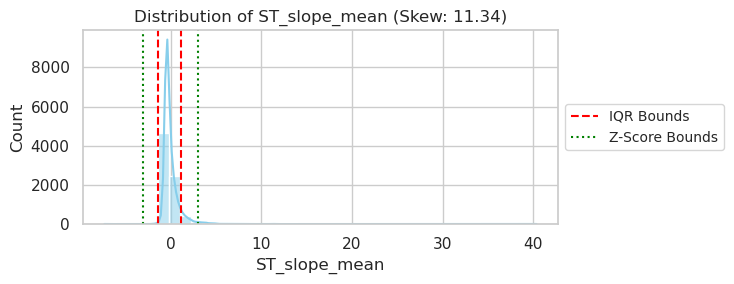

------------------------------------------------------------

------------------------------------------------------------
Feature: ST_slope_std
  - Skewness:   16.18
  - Outliers:   11.68% (905 rows outside IQR)
  - Mode Conc:  2.6% of data is exactly -0.2480
  >>> PLOTTING: High Skew Detected.


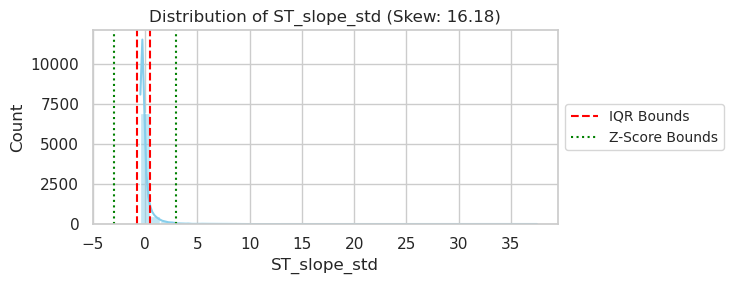

------------------------------------------------------------

------------------------------------------------------------
Feature: HRV_MeanNN
  - Skewness:   0.60
  - Outliers:   1.28% (99 rows outside IQR)
  - Mode Conc:  0.3% of data is exactly 0.7504
  >>> SKIPPING PLOT: Well-behaved distribution (Abs Skew < 1.5).
------------------------------------------------------------

------------------------------------------------------------
Feature: HRV_SDNN
  - Skewness:   4.79
  - Outliers:   13.04% (1010 rows outside IQR)
  - Mode Conc:  0.2% of data is exactly -0.5899
  >>> PLOTTING: High Skew Detected.


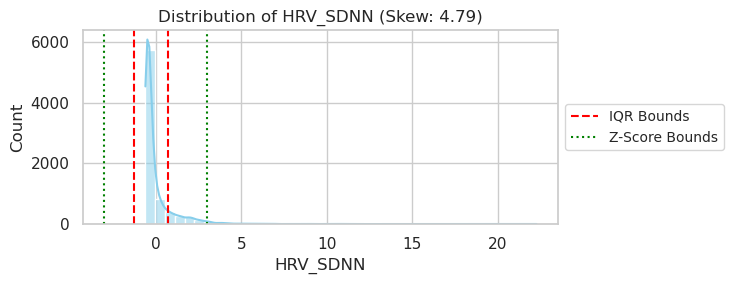

------------------------------------------------------------

------------------------------------------------------------
Feature: HRV_RMSSD
  - Skewness:   4.55
  - Outliers:   14.67% (1136 rows outside IQR)
  - Mode Conc:  0.3% of data is exactly -0.5373
  >>> PLOTTING: High Skew Detected.


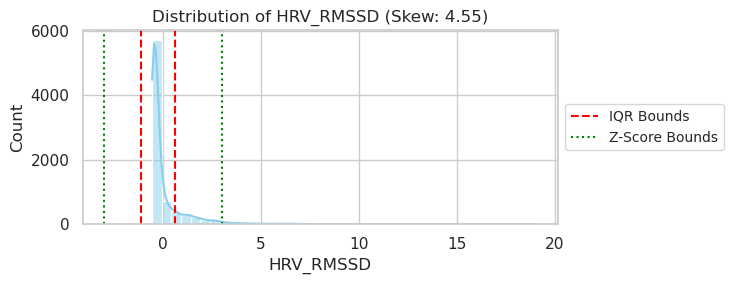

------------------------------------------------------------

------------------------------------------------------------
Feature: HRV_pNN50
  - Skewness:   1.22
  - Outliers:   3.38% (262 rows outside IQR)
  - Mode Conc:  55.6% of data is exactly -0.7064
  >>> SKIPPING PLOT: Well-behaved distribution (Abs Skew < 1.5).
------------------------------------------------------------

------------------------------------------------------------
Feature: age
  - Skewness:   -0.30
  - Outliers:   0.00% (0 rows outside IQR)
  - Mode Conc:  2.3% of data is exactly 1.3095
  >>> SKIPPING PLOT: Well-behaved distribution (Abs Skew < 1.5).
------------------------------------------------------------



In [67]:
# Identify continuous features in pruned dataset
continuous_features = [col for col in X_train_pruned.columns if X_train_pruned[col].nunique() > 10]

# Run the analyzer
for col in continuous_features:
    analyze_and_visualize_feature(X_train_pruned, col)

While several features exceed our skewness threshold of|1.5, the majority exhibit moderate skewness (between 2.0 and 3.0). The exceptions to this are the ST_slope metrics, HRV_SDNN, and HRV_RMSSD. For the HRV metrics, a right-skewed distribution is biologically expected; most individuals cluster around a standard baseline, with a long tail representing high-endurance athletes who have unusually high heart rate variability. The ST_slope metrics, however, show extreme skewness and heavy mode concentration. Further examination of these ST_slope scores is required to determine if this anomaly actually differentiates between positive and negative Chagas cases, which will dictate whether it is worth keeping for our model.

In [69]:
# 1. Find the most common value (the mode)
mode_value = X_train['ST_slope_mean'].mode()[0]

# 2. Split the target variable (y_train) into two groups based on the feature
anomalies = y_train[X_train['ST_slope_mean'] != mode_value]
mode_group = y_train[X_train['ST_slope_mean'] == mode_value]

# 3. Print the raw counts of Chagas positive/negative for both groups
print("--- Patients with the Anomaly value ---")
print(anomalies.value_counts())

print("\n--- Patients with the exact Mode value ---")
print(mode_group.value_counts())

--- Patients with the Anomaly value ---
target
0    3885
1    3855
Name: count, dtype: int64

--- Patients with the exact Mode value ---
target
1    6
Name: count, dtype: int64


These results show that the variance in ST_slope is split almost perfectly evenly (50/50) between positive and negative Chagas diagnoses. Because this feature fails to separate the two classes or reveal a distinct pattern for sick patients, it offers no predictive power. Therefore, dropping it is mathematically justified, as keeping it would only add unhelpful noise to our model.


### Phase 3: Final Selection Justifications

Based on Phase 1 (Domain-Knowledge Pruning) and the statistical screening in Phase 2, we can finalize our feature selection into four clear categories:

**1. Retaining Known Clinical Markers for Chagas Disease**
* **Observation:** Chagas disease frequently causes severe arrhythmias and electrical conduction abnormalities in the heart (such as bundle branch blocks).
* **Action:** Kept the baseline (`_mean`) and beat-to-beat variability (`_std`) for all core structural ECG features: `P_wave_duration`, `PR_interval`, `PR_segment`, `QRS_duration`, `QT_interval`, and `ST_segment`. These are established clinical markers necessary for detecting the pathologies associated with the disease.

**2. Retaining "Gold Standard" HRV Metrics**
* **Action:** Kept only the 4 clinical "Gold Standard" time-domain metrics (`HRV_MeanNN`, `HRV_SDNN`, `HRV_RMSSD`, `HRV_pNN50`) to measure autonomic nervous system health while actively preventing multicollinearity.

**3. Dropping Features Due to Lack of Information (Zero-Variance)**
* **Observation:** The automated screening showed that the remaining `ST_slope` metrics (`ST_slope_mean` and `ST_slope_std`) had a mode concentration of nearly 99% and extreme skewness. Further investigation into the rare anomalies (the remaining ~1% of variance) revealed that they were split almost perfectly (50/50) between positive and negative Chagas diagnoses.
* **Action:** Because the vast majority of patients share the exact same value, and the rare deviations fail to separate the two target classes or reveal a distinct pattern for sick patients, these features offer no predictive power. Keeping them would only add unhelpful noise to our model.

**4. Retaining Demographics**
* **Action:** `age` and `is_male` are kept as essential biological confounders, as age and sex heavily influence cardiovascular baselines.

In [70]:
# Define the final curated list of 18 features
selected_features = [
    'age', 'is_male', 
    'P_wave_duration_mean', 'P_wave_duration_std', 
    'PR_interval_mean', 'PR_interval_std', 
    'PR_segment_mean', 'PR_segment_std', 
    'QRS_duration_mean', 'QRS_duration_std', 
    'QT_interval_mean', 'QT_interval_std', 
    'ST_segment_mean', 'ST_segment_std', 
    'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50'
]

# Create the final selected datasets for modeling
X_train_final = X_train[selected_features].copy()
X_val_final = X_val[selected_features].copy()

print(f"Original Feature Count: {X_train.shape[1]}")
print(f"Final Selected Feature Count: {X_train_final.shape[1]}")

Original Feature Count: 49
Final Selected Feature Count: 18
